## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.


In [ ]:
# @title Ingrese datos
nombre_estudiante = "" # @param {"type":"string"}
carnet = None # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**


Una plataforma de streaming quiere saber cuántos suscriptores nuevos se registrarán en un mes `n`, sabiendo que el crecimiento sigue una relación de recurrencia similar a la sucesión de Fibonacci:

- En el mes 0 no hubo suscriptores nuevos: `T(0) = 0`.
- En el mes 1 se registró 1 suscriptor nuevo: `T(1) = 1`.
- A partir del mes 2, los nuevos suscriptores de un mes son la suma de los nuevos suscriptores de los dos meses anteriores (referidos del mes anterior + recomendaciones acumuladas del mes previo): `T(n) = T(n-1) + T(n-2)` para `n >= 2`.

El objetivo es calcular `T(n)` de forma eficiente usando **memoización** (programación dinámica top-down), evitando el recálculo repetido de subproblemas que ocurre en la recursión ingenua.


## 2) Requerimientos **[2 pts]**

Lista requerimientos **funcionales** y **no funcionales**.


**Requerimientos funcionales**

1. El sistema debe recibir un número entero `n >= 0` que representa el mes a consultar.
2. El sistema debe calcular `T(n)` según la relación de recurrencia definida (casos base `T(0)=0`, `T(1)=1`, y `T(n) = T(n-1) + T(n-2)` para `n >= 2`).
3. El sistema debe usar una estructura de memoización (diccionario o arreglo) para almacenar resultados ya calculados y reutilizarlos.
4. El sistema debe permitir consultar el valor de `T(n)` para distintos meses sin recalcular desde cero cada vez (la memoria persiste entre llamadas dentro de la misma ejecución).
5. El sistema debe informar el resultado de forma clara (por ejemplo: "En el mes n habrá T(n) nuevos suscriptores").

**Requerimientos no funcionales**

1. **Eficiencia:** el algoritmo debe ejecutarse en tiempo O(n), muy por debajo de la solución recursiva ingenua O(2^n).
2. **Escalabilidad:** debe soportar valores de `n` grandes (por ejemplo, varios cientos) sin exceder el límite de recursión ni el tiempo de respuesta razonable.
3. **Mantenibilidad:** el código debe estar modularizado (función independiente, documentada) para facilitar pruebas y futuras extensiones.
4. **Robustez:** el sistema debe validar que la entrada sea un entero no negativo y manejar entradas inválidas sin fallar de forma abrupta.


## 3) Historias de usuario **[2 pts]**
Escribe 3–5 historias de usuario con el formato visto en clase:
Incluye criterios de aceptación.


**Historia 1**
Como *analista de la plataforma*, quiero *consultar cuántos suscriptores nuevos habrá en un mes n* para *proyectar el crecimiento del negocio*.
- Criterio de aceptación: dado un mes `n` válido, el sistema retorna el valor correcto de `T(n)` según la recurrencia.
- Criterio de aceptación: si `n = 0` el sistema retorna 0, y si `n = 1` retorna 1.

**Historia 2**
Como *desarrollador del sistema*, quiero *que los cálculos ya realizados se guarden en memoria* para *evitar recalcular los mismos subproblemas y mejorar el rendimiento*.
- Criterio de aceptación: al consultar un `n` ya calculado previamente, el sistema no vuelve a ejecutar toda la recursión.
- Criterio de aceptación: el tiempo de ejecución crece linealmente con `n`, no exponencialmente.

**Historia 3**
Como *usuario del sistema*, quiero *recibir un mensaje de error claro si ingreso un mes inválido* para *entender qué corregí en mi entrada*.
- Criterio de aceptación: si `n` es negativo o no es un entero, el sistema informa el error sin detener la ejecución de forma inesperada.

**Historia 4**
Como *gerente de producto*, quiero *ver una gráfica comparando el crecimiento de suscriptores mes a mes* para *comunicar la tendencia al equipo ejecutivo*.
- Criterio de aceptación: el sistema permite generar y visualizar la secuencia `T(0)...T(n)`.

**Historia 5**
Como *equipo de QA*, quiero *tener pruebas automáticas del cálculo de T(n)* para *garantizar que la función funciona correctamente ante cambios futuros en el código*.
- Criterio de aceptación: existen asserts que validan casos base y casos generales conocidos de la secuencia.


## 4) Diagramas de flujo **[5 pts]**
Incluye el diagrama que muestre el proceso general

Adjunta imagen y descríbelo claramente.


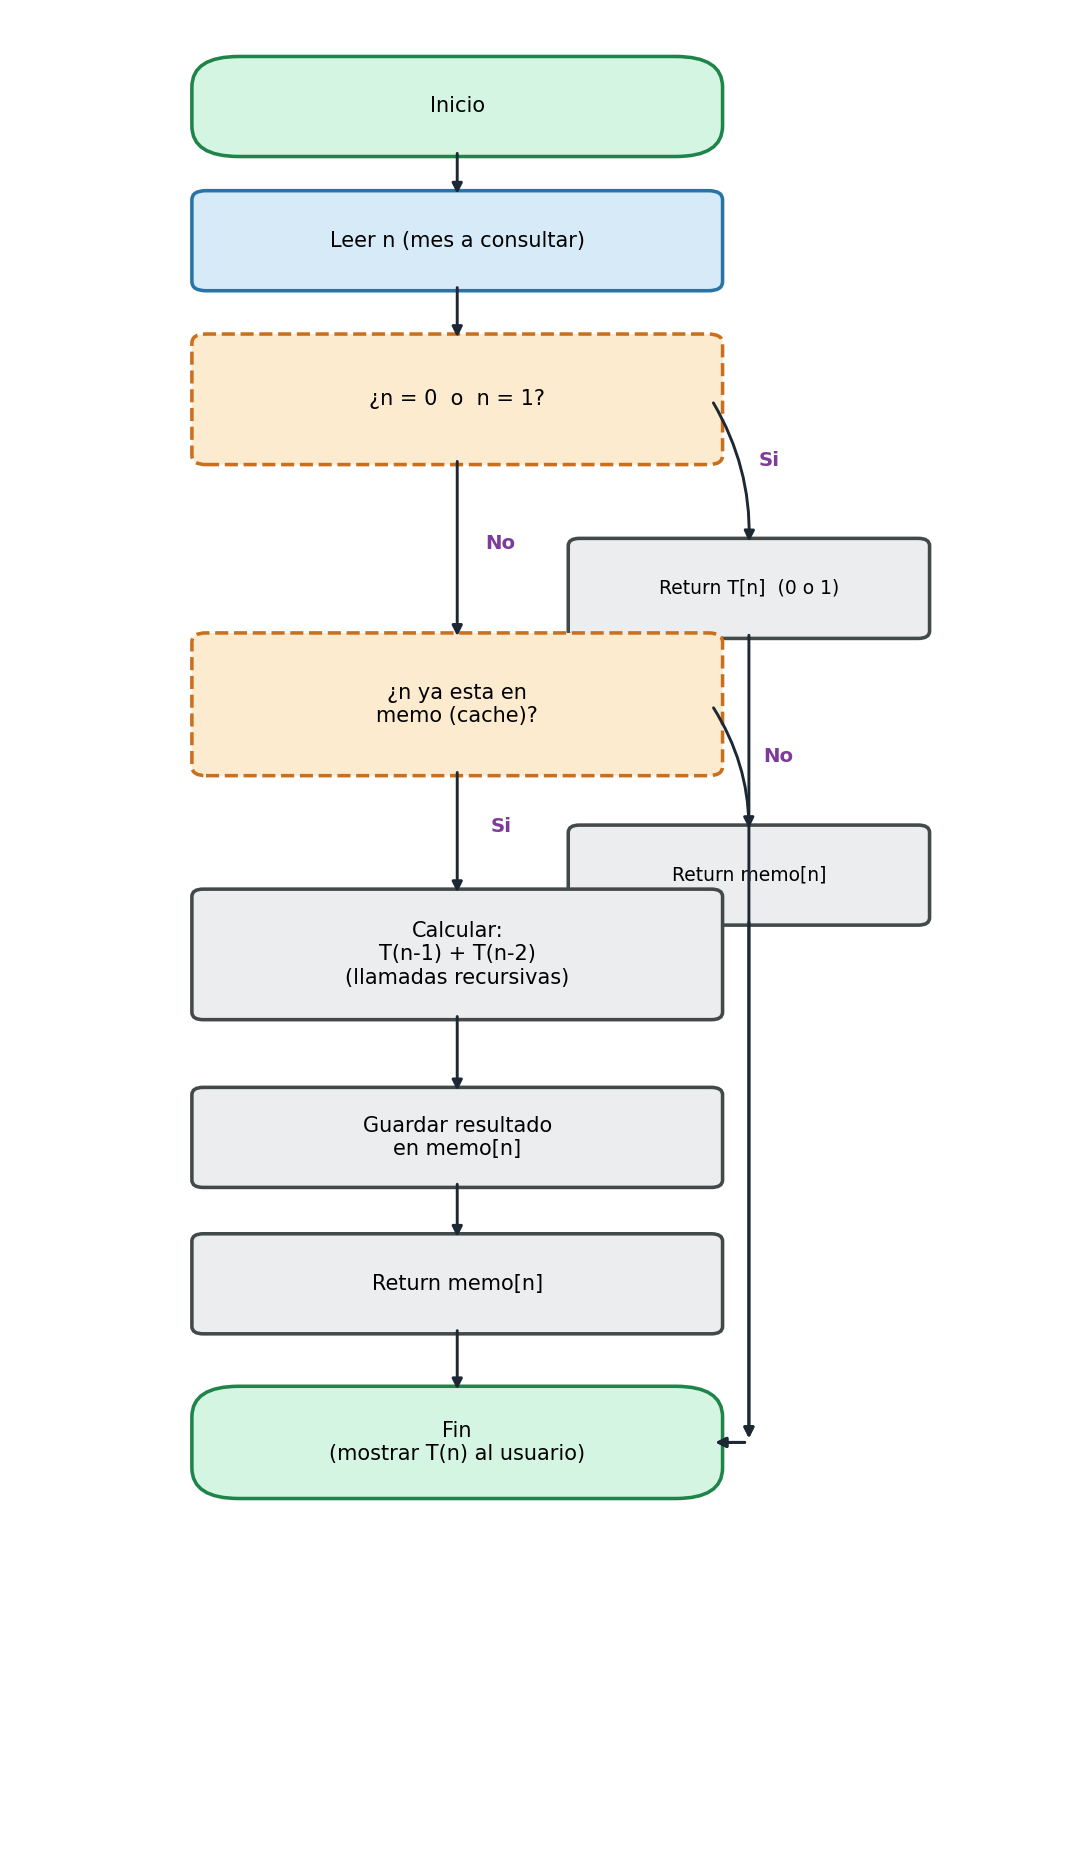


**Descripción del diagrama:**

1. El proceso inicia leyendo el mes `n` que se desea consultar.
2. Primero se evalúa si `n` corresponde a un caso base (`n = 0` o `n = 1`); si es así, se retorna directamente el valor conocido (`0` o `1`) sin necesidad de más cálculos.
3. Si no es un caso base, se revisa si `n` ya existe en la estructura de memoización (`memo`). Si ya fue calculado antes, se retorna ese valor guardado de inmediato, evitando trabajo repetido.
4. Si `n` no está en memoria, se calculan recursivamente `T(n-1)` y `T(n-2)` (cada una de estas llamadas pasa por el mismo proceso, reutilizando lo que ya esté en `memo`).
5. El resultado de `T(n-1) + T(n-2)` se guarda en `memo[n]` antes de retornarlo, de modo que si se vuelve a pedir ese mismo mes en el futuro, la respuesta sea inmediata.
6. Finalmente se muestra `T(n)` al usuario.


### 5) Análisis de complejidad **[15 pts]**
Incluye:
- Justificación
- Función T[n]
- Mejor y peor caso con gráfica


**Función de recurrencia**

$$T(n) = \begin{cases} 0 & n = 0 \\ 1 & n = 1 \\ T(n-1) + T(n-2) & n \geq 2 \end{cases}$$

**Justificación**

Sin memoización, calcular `T(n)` de forma recursiva ingenua implica volver a calcular los mismos subproblemas muchas veces: por ejemplo, `T(n-2)` se calcula tanto al resolver `T(n)` directamente como al resolver `T(n-1)`. Esto genera un árbol de recursión de tamaño exponencial, con complejidad **O(2^n)** en tiempo y **O(n)** en espacio (por la profundidad de la pila de recursión).

Con memoización, cada subproblema `T(k)` para `k` entre `0` y `n` se calcula **una sola vez** y su resultado se guarda en una estructura (diccionario o lista). Cualquier llamada posterior a `T(k)` se resuelve en tiempo O(1) consultando la memoria. Como hay exactamente `n+1` subproblemas distintos y cada uno hace trabajo constante (una suma y un acceso a memoria), la complejidad total en tiempo es **O(n)**, y en espacio es **O(n)** (por la tabla de memoización y la pila de recursión).

**Mejor y peor caso**

Con memoización, el algoritmo **no tiene casos distintos** en el sentido clásico de "mejor/peor caso" que dependan de la entrada: para calcular `T(n)` desde cero siempre se requiere resolver los `n` subproblemas una sola vez, por lo que el comportamiento es **O(n) tanto en el mejor como en el peor caso** de una primera consulta. El verdadero "mejor caso" ocurre cuando `n` ya fue calculado previamente y está en `memo`: ahí la consulta es **O(1)**. El "peor caso" es la primera consulta de un `n` grande, que es **O(n)**.

En contraste, la versión sin memoización sí varía enormemente con la entrada: su peor caso (y en la práctica su único caso relevante) es **O(2^n)**, ya que no existe forma de "acertar" un camino corto en la recursión ingenua.

La siguiente gráfica compara el número de llamadas/operaciones realizadas por la versión sin memoización (O(2^n)) contra la versión con memoización (O(n)), en escala logarítmica:


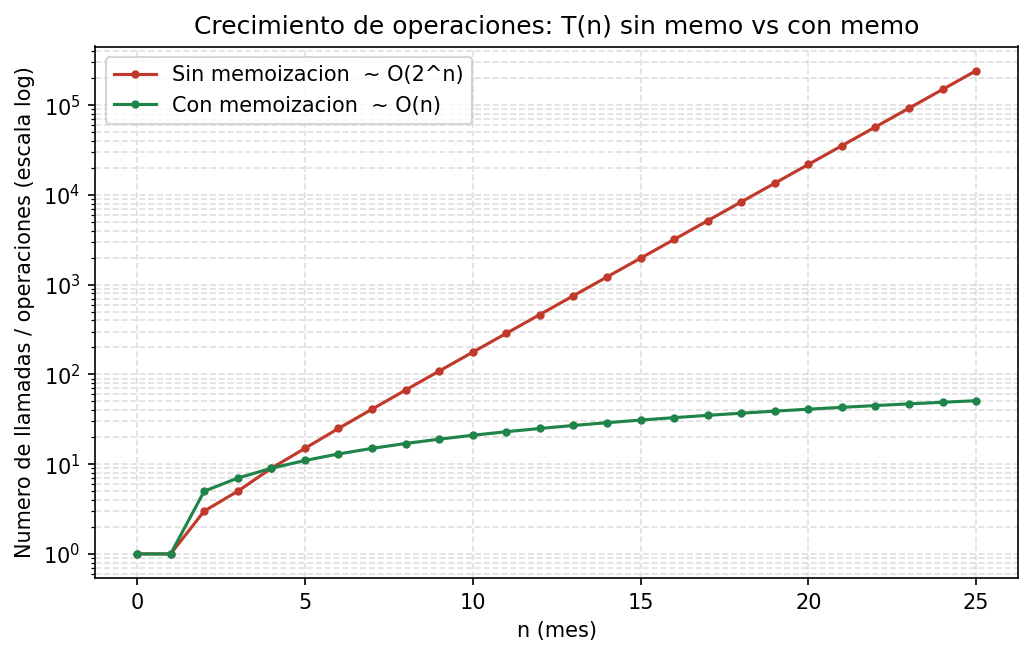


## 6) Código funcional **[15 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.


In [ ]:
def suscriptores_nuevos(n, memo=None):
    """
    Calcula T(n): numero de nuevos suscriptores en el mes n,
    usando memoizacion (programacion dinamica top-down).

    Relacion de recurrencia:
        T(0) = 0
        T(1) = 1
        T(n) = T(n-1) + T(n-2)   para n >= 2

    Parametros
    ----------
    n : int
        Mes a consultar (n >= 0).
    memo : dict, opcional
        Diccionario usado para almacenar resultados ya calculados.
        Se crea automaticamente en la primera llamada.

    Retorna
    -------
    int
        Numero de nuevos suscriptores en el mes n.
    """
    if not isinstance(n, int) or n < 0:
        raise ValueError("n debe ser un entero no negativo")

    if memo is None:
        memo = {}

    # Casos base
    if n == 0:
        return 0
    if n == 1:
        return 1

    # Si ya fue calculado, se reutiliza (memoizacion)
    if n in memo:
        return memo[n]

    # Caso recursivo: se calcula y se guarda en memo
    resultado = suscriptores_nuevos(n - 1, memo) + suscriptores_nuevos(n - 2, memo)
    memo[n] = resultado
    return resultado


def secuencia_suscriptores(n_max):
    """Retorna la lista [T(0), T(1), ..., T(n_max)] reutilizando la misma memoria."""
    memo = {}
    return [suscriptores_nuevos(k, memo) for k in range(n_max + 1)]


# Ejemplo de uso
mes_consulta = 10
print(f"Mes {mes_consulta}: {suscriptores_nuevos(mes_consulta)} nuevos suscriptores")
print("Secuencia T(0..10):", secuencia_suscriptores(10))


## 7) Tests aplicados **[15 pts]**

In [ ]:
# Casos base
assert suscriptores_nuevos(0) == 0
assert suscriptores_nuevos(1) == 1

# Casos generales (valores conocidos de la secuencia de Fibonacci)
assert suscriptores_nuevos(2) == 1
assert suscriptores_nuevos(3) == 2
assert suscriptores_nuevos(4) == 3
assert suscriptores_nuevos(5) == 5
assert suscriptores_nuevos(6) == 8
assert suscriptores_nuevos(10) == 55

# La funcion debe soportar valores grandes sin exceder el limite de recursion
assert suscriptores_nuevos(100) == 354224848179261915075

# secuencia_suscriptores debe coincidir termino a termino con suscriptores_nuevos
seq = secuencia_suscriptores(10)
assert seq == [suscriptores_nuevos(k) for k in range(11)]

# Validacion de entradas invalidas
try:
    suscriptores_nuevos(-1)
    assert False, "Se esperaba un ValueError para n negativo"
except ValueError:
    pass

try:
    suscriptores_nuevos(2.5)
    assert False, "Se esperaba un ValueError para n no entero"
except ValueError:
    pass

print("Todos los tests pasaron correctamente.")
